In [6]:
import os
os.listdir()

['.config', 'student.zip']

In [7]:
import zipfile

with zipfile.ZipFile('student.zip', 'r') as zip_ref:
    zip_ref.extractall('student_data')

print("Files extracted successfully!")


Files extracted successfully!


In [8]:
import os

os.listdir('student_data')

['student-por.csv', 'student-mat.csv', 'student-merge.R', 'student.txt']

In [9]:
import pandas as pd

df = pd.read_csv('student_data/student-mat.csv', sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


# Student Performance Analysis
This project analyzes student performance data using Python, Pandas, and Matplotlib.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [13]:
df.shape

(395, 33)

In [14]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

# Dataset Overview

The dataset contains student demographic, social, and academic information. This step examines the structure and variables present in the dataset.

In [15]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


## Missing Values Check
The dataset was checked for missing values in all columns.

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df = df.drop_duplicates()

In [18]:
df.shape

(395, 33)

## Data Cleaning

The dataset contains 395 records and 33 attributes. No duplicate records were found, so no rows were removed during the cleaning process.

In [21]:
average_grade = df['G3'].mean()
print("Average Final Grade:", average_grade)

Average Final Grade: 10.415189873417722


## Average Final Grade

The average final grade (G3) of students is **10.42**. This indicates that the overall academic performance of students is moderate.

In [22]:
high_scorers = len(df[df['G3'] > 15])

print("Students scoring above 15:", high_scorers)

Students scoring above 15: 40


## High Performing Students

A total of **40 students** scored above 15 in their final grade, indicating a relatively small group of high achievers.

In [23]:
correlation = df['studytime'].corr(df['G3'])

print("Correlation between study time and final grade:", correlation)

Correlation between study time and final grade: 0.09781968965319626


## Study Time and Academic Performance

The correlation between study time and final grade is **0.098**. This is a very weak positive correlation, suggesting that study time alone does not strongly influence final grades in this dataset.

In [24]:
gender_avg = df.groupby('sex')['G3'].mean()

print(gender_avg)

sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


## Gender-wise Performance

Female students achieved an average final grade of **9.97**, while male students achieved an average final grade of **10.91**. Based on the average final grade, male students performed slightly better in this dataset.

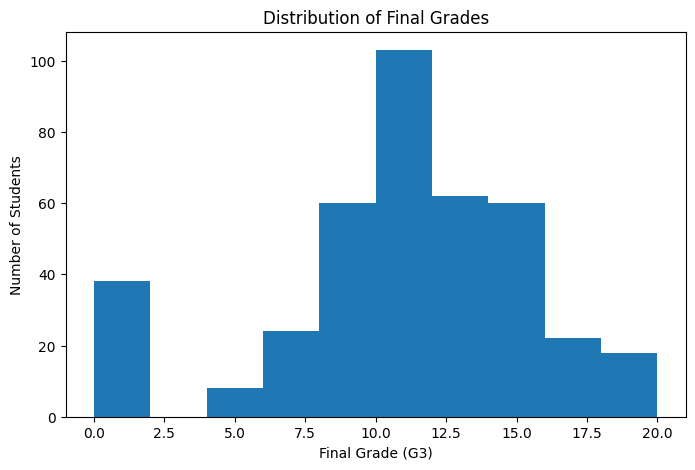

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['G3'], bins=10)
plt.title('Distribution of Final Grades')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Number of Students')
plt.show()

## Histogram of Final Grades

The histogram shows the distribution of students' final grades.

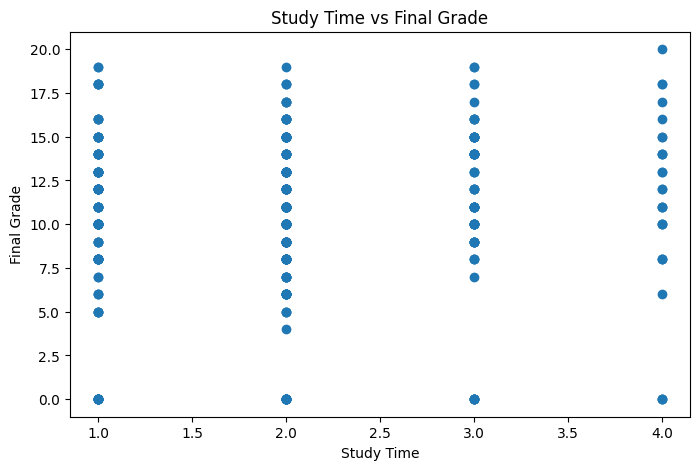

In [26]:
plt.figure(figsize=(8,5))
plt.scatter(df['studytime'], df['G3'])
plt.title('Study Time vs Final Grade')
plt.xlabel('Study Time')
plt.ylabel('Final Grade')
plt.show()

## Study Time vs Final Grade

The scatter plot illustrates the relationship between study time and final grades.

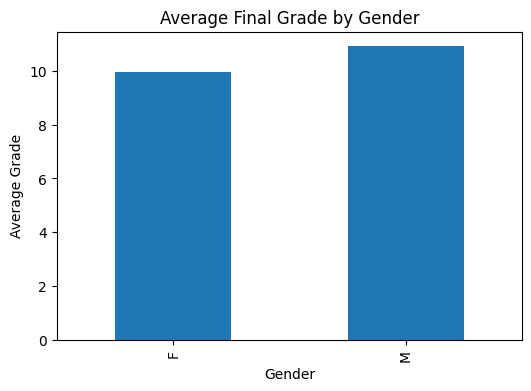

In [27]:
gender_avg = df.groupby('sex')['G3'].mean()

plt.figure(figsize=(6,4))
gender_avg.plot(kind='bar')
plt.title('Average Final Grade by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Grade')
plt.show()

## Average Grade by Gender

The bar chart compares the average final grades of male and female students.

# Conclusion

This analysis explored the Student Performance dataset and examined factors affecting academic performance.

### Key Findings

- The average final grade (G3) is 10.42.
- 40 students scored above 15 in their final grade.
- Study time has a weak positive correlation (0.098) with final grades.
- Male students achieved a slightly higher average final grade (10.91) than female students (9.97).

Visualizations were used to better understand grade distribution, study habits, and gender-based performance differences.